# Carga de datos

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline as imbPipeline


#cargar los datos tratados en la parte 1
datos = pd.read_csv('https://raw.githubusercontent.com/owaruuu/desafio-telecom-x-oracle-latam-2/refs/heads/main/datos_tratados.csv')
datos.sample(5)

,ID_Cliente,Churn,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargo_Mensual,Cargo_Total
5588,7880-XSOJX,0,Male,0,0,0,4,0,No phone service,DSL,...,Yes,No,Yes,No,No,Month-to-month,0,Mailed check,42.40,146.40
1905,2778-OCLGR,1,Male,1,1,0,24,0,No phone service,DSL,...,No,No,No,No,Yes,Month-to-month,0,Bank transfer (automatic),39.10,971.30
6456,9152-AMKAK,0,Male,0,0,0,6,1,No,DSL,...,No,Yes,Yes,Yes,Yes,Two year,1,Mailed check,80.25,493.40
6049,8590-YFFQO,0,Male,0,1,0,70,1,No,DSL,...,Yes,Yes,Yes,No,No,Two year,0,Credit card (automatic),64.95,4523.25
4528,6394-MFYNG,1,Female,0,0,0,48,1,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),107.40,5121.30


In [98]:
#Exploracion de datos
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7032 non-null   object 
 1   Churn                   7032 non-null   int64  
 2   Genero                  7032 non-null   object 
 3   Adulto_Mayor            7032 non-null   int64  
 4   Pareja                  7032 non-null   int64  
 5   Dependientes            7032 non-null   int64  
 6   Antiguedad_Meses        7032 non-null   int64  
 7   Servicio_Telefono       7032 non-null   int64  
 8   Lineas_Multiples        7032 non-null   object 
 9   Servicio_Internet       7032 non-null   object 
 10  Seguridad_Online        7032 non-null   object 
 11  Respaldo_Online         7032 non-null   object 
 12  Proteccion_Dispositivo  7032 non-null   object 
 13  Soporte_Tecnico         7032 non-null   object 
 14  TV_Streaming            7032 non-null   

In [99]:
datos[['Antiguedad_Meses','Cargo_Mensual','Cargo_Total']].sample(5)

,Antiguedad_Meses,Cargo_Mensual,Cargo_Total
7020,64,99.15,6171.20
4727,11,25.20,245.15
2389,14,19.50,272.00
2751,1,45.10,45.10
2023,30,68.95,2038.70


In [100]:
#Eliminacion de datos innecesarios
drop_datos = datos.drop(columns=['ID_Cliente'])

#Separacion de datos en Variables Explicativas y Variable Respuesta
X = drop_datos.drop(columns=['Churn'])
y = drop_datos['Churn']
print(y)

0       0
1       0
2       1
3       1
4       1
       ..
7027    0
7028    1
7029    0
7030    0
7031    0
Name: Churn, Length: 7032, dtype: int64


In [101]:
print('Genero: ',drop_datos['Genero'].unique())
print('Adulto mayor: ',drop_datos['Adulto_Mayor'].unique())
print('Pareja: ',drop_datos['Pareja'].unique())
print('Dependientes: ',drop_datos['Dependientes'].unique())
print('Servicio telefono: ',drop_datos['Servicio_Telefono'].unique())
print('Lineas multiples: ',drop_datos['Lineas_Multiples'].unique())
print('Servicio internet: ',drop_datos['Servicio_Internet'].unique())
print('Seguridad online: ',drop_datos['Seguridad_Online'].unique())
print('Respaldo online: ',drop_datos['Respaldo_Online'].unique())
print('Proteccion dispositivo: ',drop_datos['Proteccion_Dispositivo'].unique())
print('Soporte tecnico: ',drop_datos['Soporte_Tecnico'].unique())
print('TV streaming: ',drop_datos['TV_Streaming'].unique())
print('Peliculas streaming: ',drop_datos['Peliculas_Streaming'].unique())
print('Contrato: ',drop_datos['Contrato'].unique())
print('Facturacion sin papel: ',drop_datos['Facturacion_Sin_Papel'].unique())
print('Metodo pago: ',drop_datos['Metodo_Pago'].unique())

Genero:  ['Female' 'Male']
Adulto mayor:  [0 1]
Pareja:  [1 0]
Dependientes:  [1 0]
Servicio telefono:  [1 0]
Lineas multiples:  ['No' 'Yes' 'No phone service']
Servicio internet:  ['DSL' 'Fiber optic' 'No']
Seguridad online:  ['No' 'Yes' 'No internet service']
Respaldo online:  ['Yes' 'No' 'No internet service']
Proteccion dispositivo:  ['No' 'Yes' 'No internet service']
Soporte tecnico:  ['Yes' 'No' 'No internet service']
TV streaming:  ['Yes' 'No' 'No internet service']
Peliculas streaming:  ['No' 'Yes' 'No internet service']
Contrato:  ['One year' 'Month-to-month' 'Two year']
Facturacion sin papel:  [1 0]
Metodo pago:  ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [102]:
#Encoding de datos
columnas = X.columns

#Crear preprocesador
categorical_cols = ['Genero','Lineas_Multiples','Servicio_Internet','Seguridad_Online','Respaldo_Online','Proteccion_Dispositivo','Soporte_Tecnico','TV_Streaming','Peliculas_Streaming','Contrato','Metodo_Pago']
preprocessor = make_column_transformer((OneHotEncoder(drop='if_binary'),categorical_cols),remainder='passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)


In [103]:
#Calcular la proporción de clientes que se dan de baja
#Evaluamos desbalanceo.
proporcion_clase = datos['Churn'].value_counts()
proporcion_clase_normalizada = datos['Churn'].value_counts(normalize=True)
print("Proporción de clases:\n", proporcion_clase)
print()
print("Proporción de clases normalizada:\n", proporcion_clase_normalizada)
print()
print("Tasa de evasion: ", proporcion_clase[1] / (proporcion_clase[0] + proporcion_clase[1]))

Proporción de clases:
 Churn
0    5163
1    1869
Name: count, dtype: int64

Proporción de clases normalizada:
 Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Tasa de evasion:  0.26578498293515357


In [104]:
#Probar diferentes metodos de balanceo
pipeline = Pipeline([('preprocess', preprocessor), ('model', DecisionTreeClassifier(max_depth=10))])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
scoring = ['recall', 'precision', 'f1', 'roc_auc']

#Normal Model
resultados = cross_validate(pipeline, X, y, cv=skf, scoring=scoring)
resultados_df = pd.DataFrame(resultados)
resultados_df.mean()

,0
fit_time,0.106901
score_time,0.063925
test_recall,0.548439
test_precision,0.548705
test_f1,0.548466
test_roc_auc,0.749881


In [105]:
#Oversample Model
pipeline = imbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=5)),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=5))
])

oversample_resultados = cross_validate(
    pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring
)

resultados_df = pd.DataFrame(oversample_resultados)
resultados_df.mean()

,0
fit_time,0.200488
score_time,0.057668
test_recall,0.569275
test_precision,0.569073
test_f1,0.568410
test_roc_auc,0.788563


In [106]:
#Undersample Model
pipeline = imbPipeline([
    ('preprocess', preprocessor),
    ('under', NearMiss(version=3)),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=5))
])

undersample_resultados = cross_validate(pipeline, X, y, cv=skf, scoring=scoring)

resultados_df = pd.DataFrame(undersample_resultados)
resultados_df.mean()

,0
fit_time,0.214538
score_time,0.059367
test_recall,0.659740
test_precision,0.467379
test_f1,0.546878
test_roc_auc,0.722920


In [107]:
#Pruebo ocupando un modelo linear con valores escalados para comparar
numerical_cols = ['Antiguedad_Meses','Cargo_Mensual','Cargo_Total']
categorical_cols = ['Genero','Lineas_Multiples','Servicio_Internet','Seguridad_Online','Respaldo_Online','Proteccion_Dispositivo','Soporte_Tecnico','TV_Streaming','Peliculas_Streaming','Contrato','Metodo_Pago']

preprocessor = make_column_transformer(
    (OneHotEncoder(drop='if_binary'),categorical_cols),
    (MinMaxScaler(), numerical_cols),
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

logistic_reg_resultados = cross_validate(pipeline, X, y, cv=skf, scoring=scoring)

resultados_df = pd.DataFrame(logistic_reg_resultados)
resultados_df.mean()



,0
fit_time,0.159723
score_time,0.093607
test_recall,0.544147
test_precision,0.654299
test_f1,0.594106
test_roc_auc,0.843600


In [108]:
def resumen_cv(nombre_modelo, cv_resultados):
    df = pd.DataFrame(cv_resultados).filter(like='test_')
    return pd.Series({
        'Model': nombre_modelo,
        'Recall': df['test_recall'].mean(),
        'Precision': df['test_precision'].mean(),
        'F1': df['test_f1'].mean(),
        'ROC_AUC': df['test_roc_auc'].mean()
    })

tabla_final = pd.DataFrame([
    resumen_cv("Original", resultados),
    resumen_cv("Oversample", oversample_resultados),
    resumen_cv("Undersample", undersample_resultados),
    resumen_cv("Logistic regression", logistic_reg_resultados)
])

tabla_final

#Podemos apreciar que el mejor modelo a ocupar es 'Logistic Regression', ya que mantiene su puntaje de 'Recall', mejora su 'Precision' bastante y tambien su 'ROC_AUC', Lo que significa que podemos
#Mantener nuestra capacidad de encontrar personas que dan de bajar el servicio y subimos nuestra capacidad de estar correctos cuando decimos que alguien dara de baja.

,Model,Recall,Precision,F1,ROC_AUC
0,Original,0.548439,0.548705,0.548466,0.749881
1,Oversample,0.569275,0.569073,0.568410,0.788563
2,Undersample,0.659740,0.467379,0.546878,0.722920
3,Logistic regression,0.544147,0.654299,0.594106,0.843600


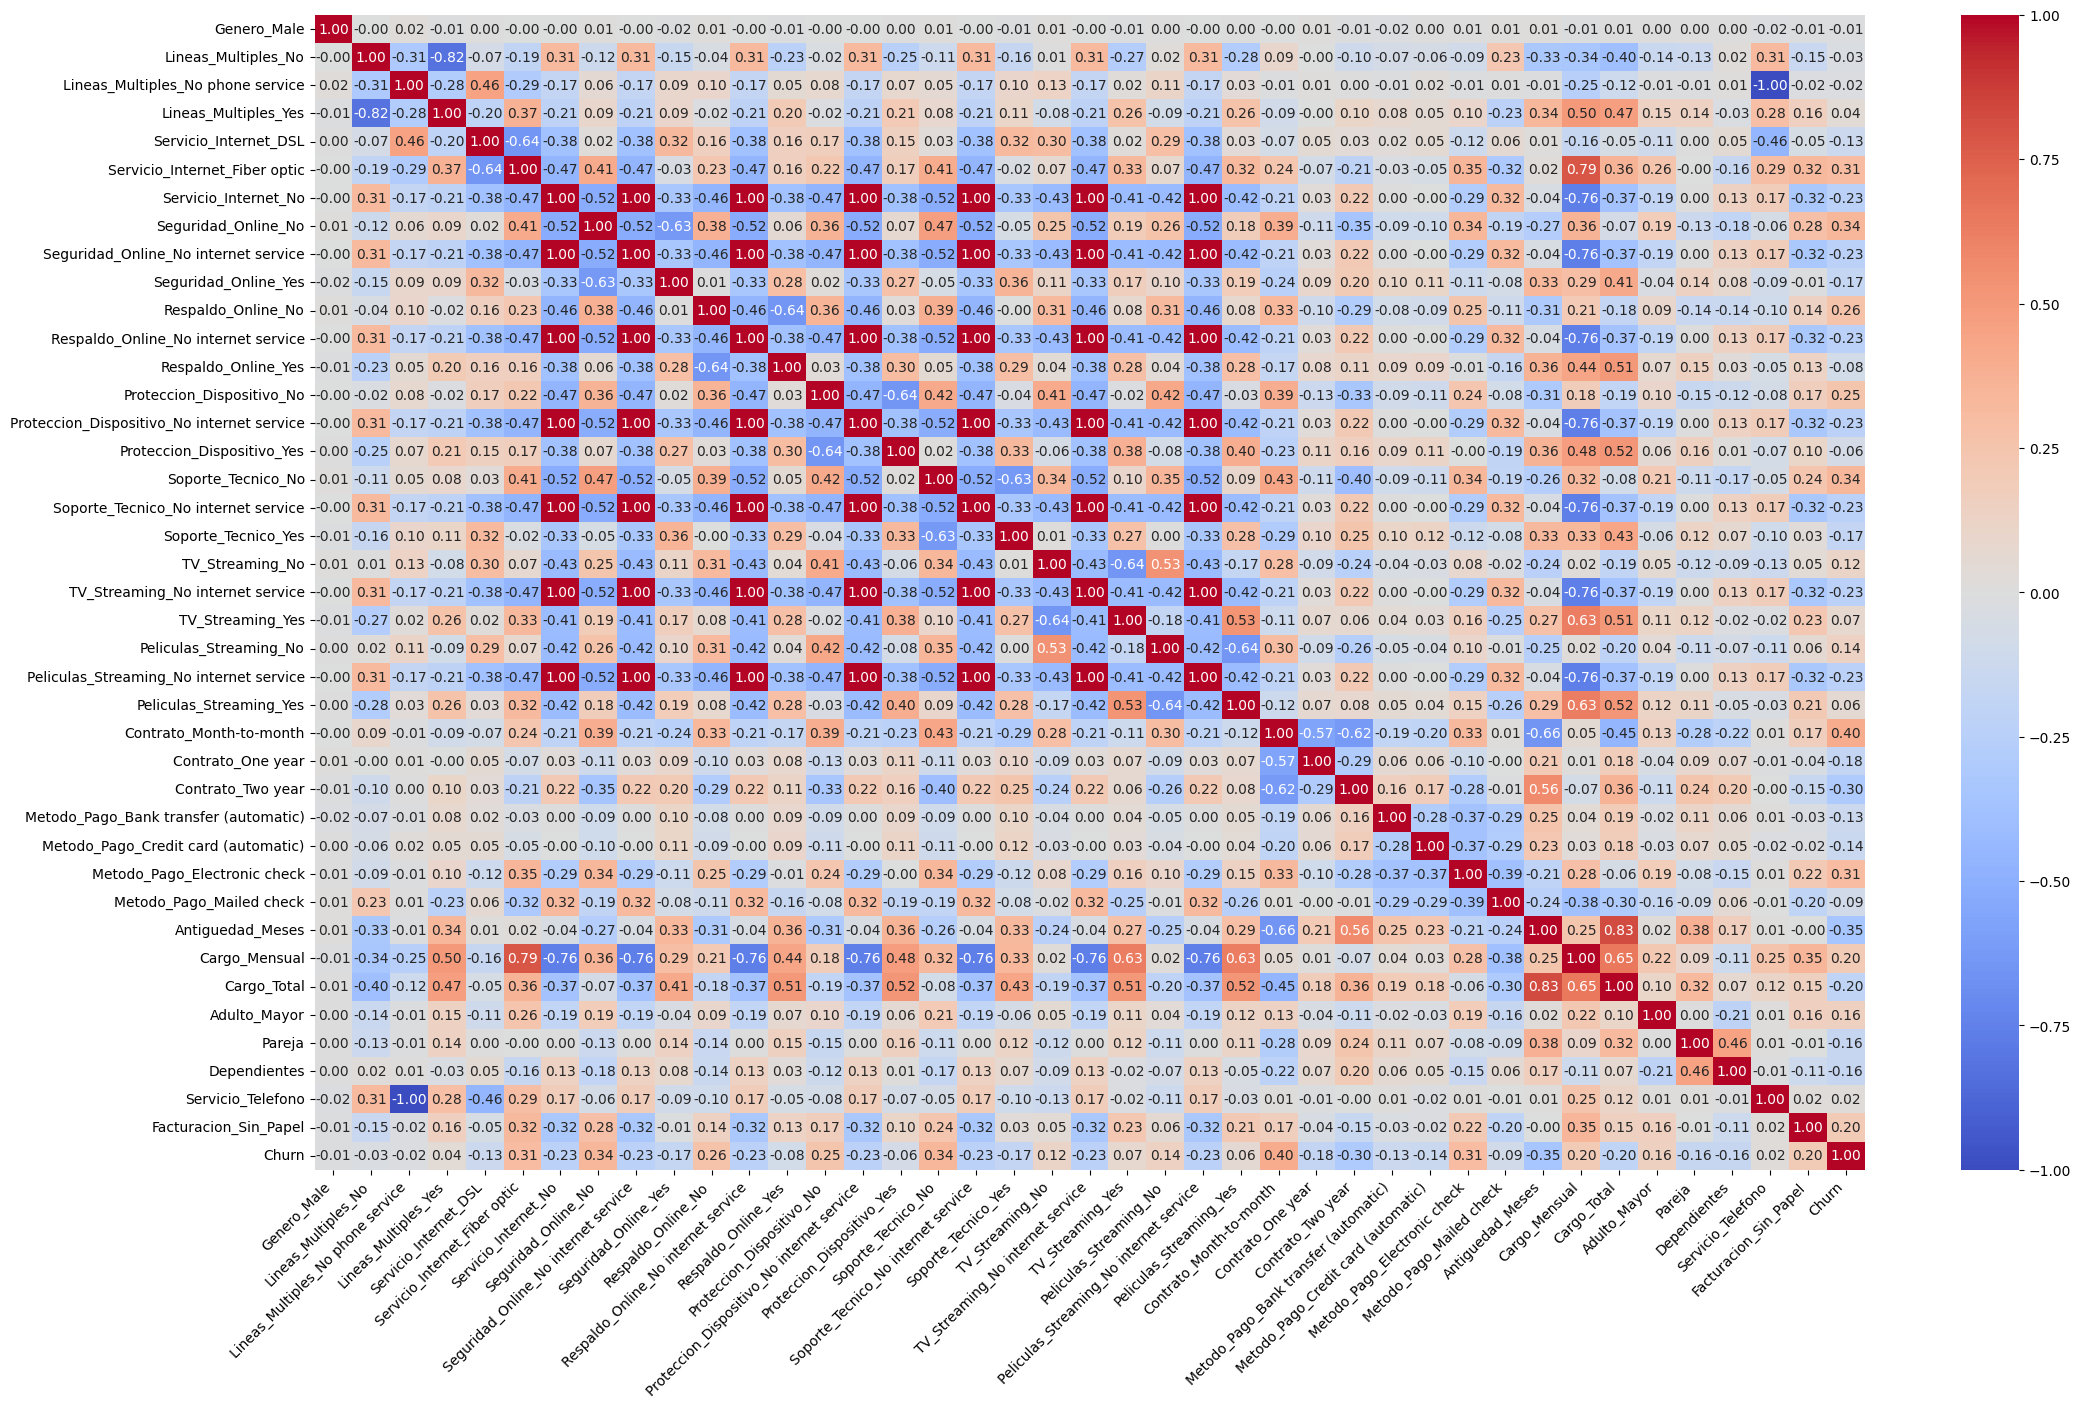

In [109]:
#Analisis de correlacion
#Matriz de correlacion
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
pipeline.fit(X_train, y_train)

X_transformed =pipeline.named_steps['preprocess'].transform(X_train)
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
clean_feature_names = [name.split("__")[-1] for name in feature_names]

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=clean_feature_names
)

X_transformed_df["Churn"] = y_train.reset_index(drop=True)

corr_matrix = X_transformed_df.corr(method='pearson')

plt.figure(figsize=(25,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45, ha='right')

plt.show()



In [110]:
#Analisando los resultados del 'correlation matrix' podemos notar que las variables que afectan mas (arriba de 0.3) en la baja del servicio son:
#Tener fibra, no tener el servicio de seguridad online, no tener servicio tecnico, tener un contrato de mes a mes y pagar con cheque electronico.
#Al mismo tiempo, 2 variables que influyen mas en que las personas mantengan su servicio son: contratos de 2 años y llevar mas meses con el servicio contratado.

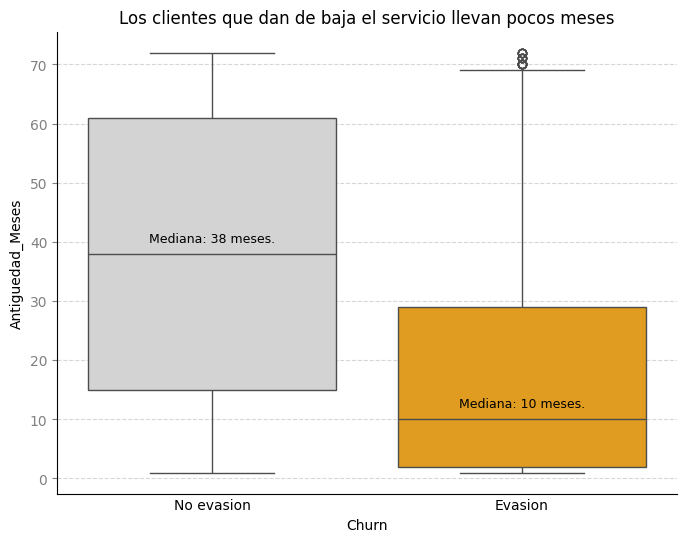

In [111]:
#Comparacion Tiempo de contrato X Cancelacion
plt.figure(figsize=(8, 6))
evasion_clientes = drop_datos['Churn'].map({0: 'No evasion', 1: 'Evasion'})

sns.boxplot(x='Churn', y='Antiguedad_Meses', data=drop_datos,palette={'No evasion': 'lightgray', 'Evasion': 'orange'},
    hue=evasion_clientes,legend=False)
sns.despine()

mediana_no_evasion = drop_datos.loc[evasion_clientes == 'No evasion', 'Antiguedad_Meses'].median()
mediana_evasion = drop_datos.loc[evasion_clientes == 'Evasion', 'Antiguedad_Meses'].median()

plt.xticks([0,1], ['No evasion', 'Evasion'])

plt.text(
    0, mediana_no_evasion + 2,
    f'Mediana: {int(mediana_no_evasion)} meses.',
    ha='center',
    fontsize=9,
)

plt.text(
    1, mediana_evasion + 2,
    f'Mediana: {int(mediana_evasion)} meses.',
    ha='center',
    fontsize=9,
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(color='gray')
plt.tick_params(axis='y', color='gray')
plt.tick_params(axis='x', size=0)
plt.title('Los clientes que dan de baja el servicio llevan pocos meses')
plt.show()

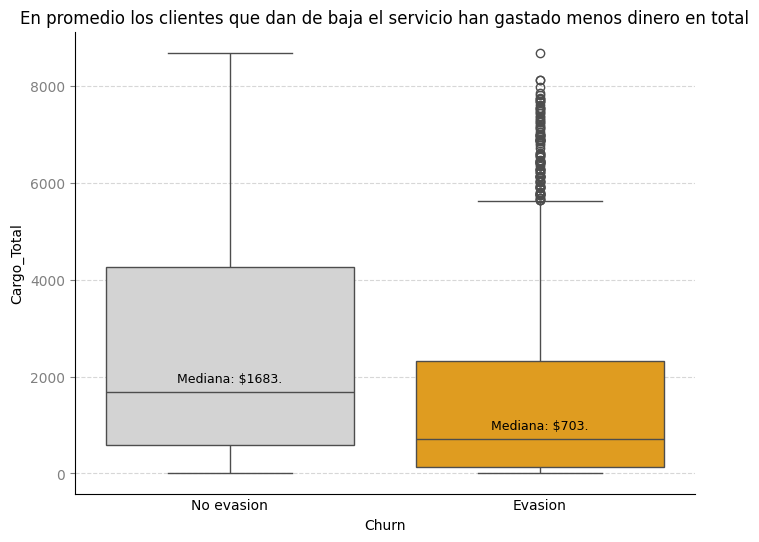

In [112]:
#Comparacion Gasto Total X Cancelacion
plt.figure(figsize=(8, 6))
evasion_clientes = drop_datos['Churn'].map({0: 'No evasion', 1: 'Evasion'})

sns.boxplot(x='Churn', y='Cargo_Total', data=drop_datos,palette={'No evasion': 'lightgray', 'Evasion': 'orange'},
    hue=evasion_clientes,legend=False)
sns.despine()

mediana_no_evasion = drop_datos.loc[evasion_clientes == 'No evasion', 'Cargo_Total'].median()
mediana_evasion = drop_datos.loc[evasion_clientes == 'Evasion', 'Cargo_Total'].median()

plt.xticks([0,1], ['No evasion', 'Evasion'])

plt.text(
    0, mediana_no_evasion + 200,
    f'Mediana: ${int(mediana_no_evasion)}.',
    ha='center',
    fontsize=9,
)

plt.text(
    1, mediana_evasion + 200,
    f'Mediana: ${int(mediana_evasion)}.',
    ha='center',
    fontsize=9,
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(color='gray')
plt.tick_params(axis='y', color='gray')
plt.tick_params(axis='x', size=0)
plt.title('En promedio los clientes que dan de baja el servicio han gastado menos dinero en total')
plt.show()

In [113]:
#Comparacion de 2 modelos distintos
scoring = ['accuracy', 'recall', 'precision', 'f1']

#modelo normal para tener de referencia
pipeline = Pipeline([('preprocess', preprocessor), ('model', DecisionTreeClassifier(max_depth=10))])
resultados = cross_validate(pipeline, X, y, cv=skf, scoring=scoring)

#Oversample Model
oversample_pipeline = imbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=5)),
    ('model', DecisionTreeClassifier(max_depth=10, random_state=5))
])

oversample_resultados = cross_validate(
    oversample_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring
)

#Logistic Regression
numerical_cols = ['Antiguedad_Meses','Cargo_Mensual','Cargo_Total']
categorical_cols = ['Genero','Lineas_Multiples','Servicio_Internet','Seguridad_Online','Respaldo_Online','Proteccion_Dispositivo','Soporte_Tecnico','TV_Streaming','Peliculas_Streaming','Contrato','Metodo_Pago']

preprocessor = make_column_transformer(
    (OneHotEncoder(drop='if_binary'),categorical_cols),
    (MinMaxScaler(), numerical_cols),
    remainder='passthrough'
)

logistic_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

logistic_reg_resultados = cross_validate(logistic_pipeline, X, y, cv=skf, scoring=scoring)


#Resumen
def resumen_cv(nombre_modelo, cv_resultados):
    df = pd.DataFrame(cv_resultados).filter(like='test_')
    return pd.Series({
        'Model': nombre_modelo,
        'Accuracy': df['test_accuracy'].mean(),
        'Recall': df['test_recall'].mean(),
        'Precision': df['test_precision'].mean(),
        'F1': df['test_f1'].mean(),
    })

tabla_final = pd.DataFrame([
    resumen_cv('Normal model', resultados),
    resumen_cv("Oversample", oversample_resultados),
    resumen_cv("Logistic regression", logistic_reg_resultados)
])

tabla_final

,Model,Accuracy,Recall,Precision,F1
0,Normal model,0.760239,0.549510,0.548782,0.549054
1,Oversample,0.741610,0.665050,0.510954,0.577775
2,Logistic regression,0.802332,0.544147,0.654299,0.594106


El modelo de regresion logistica tiene el rendimiento general mejor con un accuracy de 80.2% in puntaje F1 de 0.59.
Pero el modelo de oversampling tiene mejor recall (0.665) por lo tanto puede identificar mas gente que va a dar de baja el servicio.

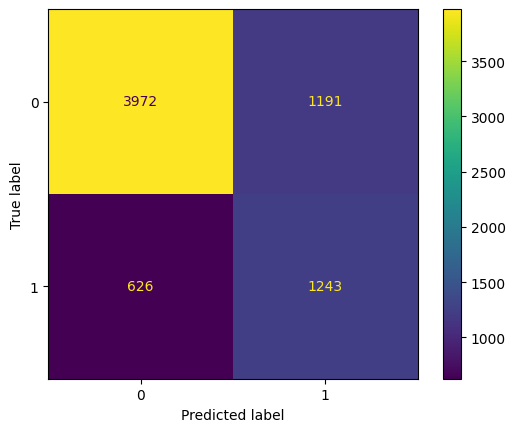

In [114]:
#Matriz de confusion
#Oversample model
oversample_y_pred = cross_val_predict(oversample_pipeline, X, y, cv=skf)
oversample_cm = confusion_matrix(y, oversample_y_pred)

oversample_cm = confusion_matrix(y, oversample_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=oversample_cm)
disp.plot()

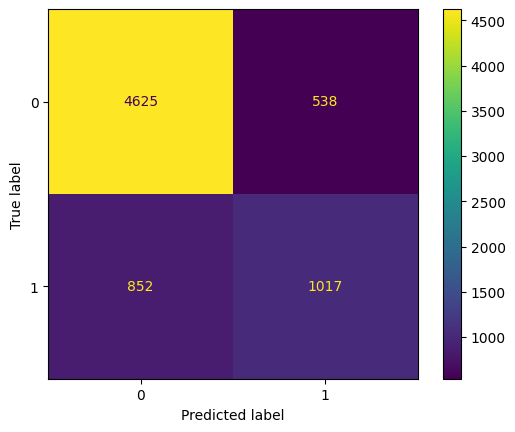

In [115]:
#Matriz de confusion
#Logistic model
logistic_y_pred = cross_val_predict(logistic_pipeline, X, y, cv=skf)
logistic_cm = confusion_matrix(y, logistic_y_pred)

logistic_cm = confusion_matrix(y, logistic_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=logistic_cm)
disp.plot()

El modelo de oversampling identifica mas clientes que iban a dar de baja su servicio (1243 verdaderos positivos) y pierde menos gente (626 falsos negativos)
Pero, produce mas falsos positivos, lo que puede provocar costos de retencion innecesarios.

In [116]:
#Coeficientes modelo Logistic Regression
coef_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

coef_pipeline.fit(X, y)
feature_names = coef_pipeline.named_steps["preprocess"].get_feature_names_out()
coef = coef_pipeline.named_steps["model"].coef_[0]

clean_feature_names = [name.split("__")[-1] for name in feature_names]

transformed_coef_df  = pd.DataFrame({
    "Feature":clean_feature_names,
    "Coefficient": coef
})

coef_df = transformed_coef_df .sort_values(by="Coefficient", ascending=False)


In [119]:
coef_df.head(5)

,Feature,Coefficient
34,Cargo_Total,1.499515
25,Contrato_Month-to-month,0.609271
5,Servicio_Internet_Fiber optic,0.391292
39,Facturacion_Sin_Papel,0.338714
30,Metodo_Pago_Electronic check,0.214184


In [120]:
coef_df.tail(5)

,Feature,Coefficient
38,Servicio_Telefono,-0.248702
1,Lineas_Multiples_No,-0.255352
4,Servicio_Internet_DSL,-0.431340
27,Contrato_Two year,-0.740304
32,Antiguedad_Meses,-3.315352


Las variables que mas influyen en la probabilidad de dar de baja el servicio son el contrato de mes a mes y tener contratado el internet de fibra.
Y las que influyen en que el cliente se quede son cuantos meses ya lleva contratando y tener contratos de 2 años.
El cargo total tiene una probabilidad grande pero eso puede ser una combinacion de factores.

In [ ]:
# Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

# Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

# Conclusion

Despues de preparar los datos para ser usados con modelos se probaron 3 tipos: Un Decision Tree con Over Sampling, uno con Under Sampling y un modelo Linear de Logistic Regression.

Basado en los resultados de Cross Validation se eligio como los mejores modelos el con Over Sampling y el de Logistic Regression.

Al revisar los coeficientes de las variables se sacaron las siguientes conclusiones:

Las variables que mas influyen en la probabilidad de dar de baja el servicio son el contrato de mes a mes y tener contratado el internet de fibra.
Y las que influyen en que el cliente se quede son cuantos meses ya lleva contratando y tener contratos de 2 años.
El cargo total tiene una probabilidad grande pero eso puede ser una combinacion de factores.

# Recomendaciones

- Implementar algun tipo de oferta que le de acceso al servicio tecnico a clientes de fibra para ver si eso afecta la tasa de evasion. Vigilar el cambio en el coeficiente despues de implementar.
- Implementar ofertas especiales para mover clientes a contratos 2 años.
- Implementar ofertas y tratado especial los primeros meses que ayuden a evitar que los clientes den de baja el servicio.
- Incentivar a los usuarios a ocupar sistemas de pago automaticos con ofertas exclusivas.
